In [1]:
# ToxLens | 03 — GNN (AttentiveFP)
### Graph Neural Network for multi-task toxicity prediction
### Baseline to beat: Mean AUC-ROC = 0.8566 (XGBoost)

In [2]:
from google.colab import files
files.upload()  # upload kaggle.json

import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle datasets download -d epicskills/tox21-dataset --unzip -p /content/tox21/ -q
!kaggle datasets download -d basu369victor/zinc250k --unzip -p /content/zinc250k/ -q

!pip install rdkit deepchem imbalanced-learn -q

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem, QED
from rdkit.Chem.inchi import MolToInchiKey

tox21_df = pd.read_csv('/content/tox21/tox21.csv')
zinc_df  = pd.read_csv('/content/zinc250k/250k_rndm_zinc_drugs_clean_3.csv')
zinc_df['smiles'] = zinc_df['smiles'].str.strip()

def is_valid_smiles(smi):
    try: return Chem.MolFromSmiles(str(smi)) is not None
    except: return False

def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None: return [np.nan] * 8
    return [Descriptors.MolWt(mol), Descriptors.MolLogP(mol),
            Descriptors.NumHDonors(mol), Descriptors.NumHAcceptors(mol),
            Descriptors.TPSA(mol), rdMolDescriptors.CalcNumRings(mol),
            rdMolDescriptors.CalcNumAromaticRings(mol), Descriptors.FractionCSP3(mol)]

def get_inchikey(smi):
    try:
        mol = Chem.MolFromSmiles(str(smi))
        return MolToInchiKey(mol) if mol else None
    except: return None

def smiles_to_fp(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None: return np.zeros(n_bits)
    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits))

tox21_df = tox21_df[tox21_df['smiles'].apply(is_valid_smiles)].reset_index(drop=True)

desc_cols = ['MolWt','LogP','HBD','HBA','TPSA','NumRings','AromaticRings','FractionCSP3']
desc_df   = pd.DataFrame(tox21_df['smiles'].apply(compute_descriptors).tolist(), columns=desc_cols)
tox21_df  = pd.concat([tox21_df, desc_df], axis=1)

tox21_df['inchikey'] = tox21_df['smiles'].apply(get_inchikey)
zinc_df['inchikey']  = zinc_df['smiles'].apply(get_inchikey)
zinc_features        = zinc_df[['inchikey','logP','qed','SAS']].dropna(subset=['inchikey'])
tox21_df             = tox21_df.merge(zinc_features, on='inchikey', how='left')

mask = tox21_df['qed'].isna()
tox21_df.loc[mask, 'logP'] = tox21_df.loc[mask, 'smiles'].apply(
    lambda s: Descriptors.MolLogP(Chem.MolFromSmiles(str(s))) if Chem.MolFromSmiles(str(s)) else np.nan)
tox21_df.loc[mask, 'qed']  = tox21_df.loc[mask, 'smiles'].apply(
    lambda s: QED.qed(Chem.MolFromSmiles(str(s))) if Chem.MolFromSmiles(str(s)) else np.nan)

fp_matrix = np.vstack(tox21_df['smiles'].apply(smiles_to_fp).values)

os.makedirs('/content/processed', exist_ok=True)
tox21_df.to_csv('/content/processed/tox21_processed.csv', index=False)
np.save('/content/processed/fp_matrix.npy', fp_matrix)

print(f"Ready. Compounds: {len(tox21_df)} | FP shape: {fp_matrix.shape}")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/epicskills/tox21-dataset
License(s): DbCL-1.0
Dataset URL: https://www.kaggle.com/datasets/basu369victor/zinc250k
License(s): DbCL-1.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.4/552.4 kB 33.1 MB/s eta 0:00:00


Streaming output truncated to the last 5000 lines.
[15:22:53] DEPRECATION WARNING: please use MorganGenerator
[15:22:53] DEPRECATION WARNING: please use MorganGenerator
[15:22:53] DEPRECATION WARNING: please use MorganGenerator
[15:22:53] DEPRECATION WARNING: please use MorganGenerator
[15:22:53] DEPRECATION WARNING: please use MorganGenerator
[15:22:53] DEPRECATION WARNING: please use MorganGenerator
[15:22:53] DEPRECATION WARNING: please use MorganGenerator
[15:22:53] DEPRECATION WARNING: please use MorganGenerator
[15:22:53] DEPRECATION WARNING: please use MorganGenerator
[15:22:53] DEPRECATION WARNING: please use MorganGenerator
[15:22:53] DEPRECATION WARNING: please use MorganGenerator
[15:22:53] DEPRECATION WARNING: please use MorganGenerator
[15:22:53] DEPRECATION WARNING: please use MorganGenerator
[15:22:53] DEPRECATION WARNING: please use MorganGenerator
[15:22:53] DEPRECATION WARNING: please use MorganGenerator
[15:22:53] DEPRECATION WARNING: please use MorganGenerator
[15:2

Ready. Compounds: 7823 | FP shape: (7823, 2048)


In [3]:
#Cell — Install PyTorch Geometric
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Install PyG matching current torch version
!pip install torch-geometric -q
!pip install torch-scatter torch-sparse -q \
    -f https://data.pyg.org/whl/torch-$(python -c "import torch; print(torch.__version__)")+cu121.html

PyTorch version: 2.10.0+cpu
CUDA available: False
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 8.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 18.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [5]:
!pip install mlflow torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.7/837.7 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 15.1 MB/s eta 0:00:00


In [6]:
#Cell — GNN imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import AttentiveFP
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import mlflow
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

assay_cols = ['NR-AR','NR-AR-LBD','NR-AhR','NR-Aromatase',
              'NR-ER','NR-ER-LBD','NR-PPAR-gamma',
              'SR-ARE','SR-ATAD5','SR-HSE','SR-MMP','SR-p53']
N_TASKS = len(assay_cols)

Device: cpu


In [7]:
#Cell — Atom and bond featurizers
from rdkit.Chem import rdchem

def atom_features(atom):
    return [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetTotalNumHs(),
        atom.GetImplicitValence(),
        int(atom.GetIsAromatic()),
        int(atom.IsInRing()),
        atom.GetFormalCharge(),
        int(atom.GetHybridization() == rdchem.HybridizationType.SP),
        int(atom.GetHybridization() == rdchem.HybridizationType.SP2),
    ]

def bond_features(bond):
    bt = bond.GetBondType()
    return [
        int(bt == rdchem.BondType.SINGLE),
        int(bt == rdchem.BondType.DOUBLE),
        int(bt == rdchem.BondType.TRIPLE),
        int(bt == rdchem.BondType.AROMATIC),
        int(bond.IsInRing()),
        int(bond.GetIsConjugated()),
    ]

def mol_to_graph(smiles, labels):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None

    # Node features
    x = torch.tensor([atom_features(a) for a in mol.GetAtoms()],
                     dtype=torch.float)

    # Edge index + edge features
    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bf    = bond_features(bond)
        edge_index += [[i, j], [j, i]]
        edge_attr  += [bf, bf]

    if len(edge_index) == 0:
        return None

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr  = torch.tensor(edge_attr,  dtype=torch.float)

    # Labels — NaN → -1 (masked in loss)
    y = torch.tensor(
        [float(l) if not np.isnan(float(l)) else -1.0 for l in labels],
        dtype=torch.float
    ).unsqueeze(0)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

print("Featurizers defined.")
print(f"  Atom features: 9")
print(f"  Bond features: 6")

Featurizers defined.
  Atom features: 9
  Bond features: 6


In [8]:
#Cell — Build graph dataset
print("Building molecular graphs...")
graphs = []
skipped = 0

for idx, row in tox21_df.iterrows():
    labels = [row[a] for a in assay_cols]
    g = mol_to_graph(row['smiles'], labels)
    if g is not None:
        graphs.append(g)
    else:
        skipped += 1

print(f"Graphs built:  {len(graphs)}")
print(f"Skipped:       {skipped}")
print(f"Node feat dim: {graphs[0].x.shape[1]}")
print(f"Edge feat dim: {graphs[0].edge_attr.shape[1]}")

Building molecular graphs...


Streaming output truncated to the last 5000 lines.
[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.

Graphs built:  7804
Skipped:       19
Node feat dim: 9
Edge feat dim: 6


[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:56:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:56:07] DEPRECATIO

In [9]:
#Cell — Train/val/test split
n       = len(graphs)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)
n_test  = n - n_train - n_val

torch.manual_seed(42)
perm         = torch.randperm(n).tolist()
train_graphs = [graphs[i] for i in perm[:n_train]]
val_graphs   = [graphs[i] for i in perm[n_train:n_train+n_val]]
test_graphs  = [graphs[i] for i in perm[n_train+n_val:]]

train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_graphs,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_graphs,  batch_size=64, shuffle=False)

print(f"Train: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")

Train: 6243 | Val: 780 | Test: 781


In [10]:
#Cell — AttentiveFP model
class ToxLensGNN(nn.Module):
    def __init__(self, in_channels, edge_dim, hidden, n_tasks,
                 num_layers=3, num_timesteps=2, dropout=0.2):
        super().__init__()
        self.gnn = AttentiveFP(
            in_channels=in_channels,
            hidden_channels=hidden,
            out_channels=hidden,
            edge_dim=edge_dim,
            num_layers=num_layers,
            num_timesteps=num_timesteps,
            dropout=dropout
        )
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, n_tasks)
        )

    def forward(self, x, edge_index, edge_attr, batch):
        out = self.gnn(x, edge_index, edge_attr, batch)
        return self.head(out)

NODE_DIM  = graphs[0].x.shape[1]       # 9
EDGE_DIM  = graphs[0].edge_attr.shape[1]  # 6
HIDDEN    = 200
N_LAYERS  = 3
N_TIMES   = 2
DROPOUT   = 0.2

model = ToxLensGNN(NODE_DIM, EDGE_DIM, HIDDEN, N_TASKS,
                   N_LAYERS, N_TIMES, DROPOUT).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(model)

Model parameters: 1,231,912
ToxLensGNN(
  (gnn): AttentiveFP(in_channels=9, hidden_channels=200, out_channels=200, edge_dim=6, num_layers=3, num_timesteps=2)
  (head): Sequential(
    (0): Linear(in_features=200, out_features=100, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=100, out_features=12, bias=True)
  )
)


In [11]:
#Cell — Masked loss function
def masked_bce_loss(pred, target):
    """
    Ignore positions where target == -1 (missing labels).
    """
    mask   = (target != -1).float()
    target = target.clamp(min=0)
    loss   = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
    return (loss * mask).sum() / mask.sum().clamp(min=1)

In [13]:
#Cell — Training loop
EPOCHS   = 50
LR       = 1e-3
PATIENCE = 8

optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                               patience=3)

mlflow.set_experiment("ToxLens_GNN_AttentiveFP")

best_val_loss = float('inf')
patience_ctr  = 0
train_losses  = []
val_losses    = []

print(f"Training AttentiveFP | {EPOCHS} epochs | device: {DEVICE}")
print("=" * 55)

with mlflow.start_run(run_name="AttentiveFP_multitask"):
    mlflow.log_params({
        'hidden': HIDDEN, 'n_layers': N_LAYERS,
        'n_timesteps': N_TIMES, 'dropout': DROPOUT,
        'lr': LR, 'batch_size': 64, 'epochs': EPOCHS
    })

    for epoch in range(1, EPOCHS + 1):
        # Train
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = masked_bce_loss(pred, batch.y.squeeze(1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        avg_train = total_loss / len(train_loader)

        # Validate
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(DEVICE)
                pred  = model(batch.x, batch.edge_index,
                              batch.edge_attr, batch.batch)
                val_loss += masked_bce_loss(pred, batch.y.squeeze(1)).item()
        avg_val = val_loss / len(val_loader)

        train_losses.append(avg_train)
        val_losses.append(avg_val)
        scheduler.step(avg_val)

        mlflow.log_metrics({'train_loss': avg_train, 'val_loss': avg_val}, step=epoch)

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:>3} | Train: {avg_train:.4f} | Val: {avg_val:.4f}")

        # Early stopping
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            patience_ctr  = 0
            torch.save(model.state_dict(), '/content/processed/gnn_best.pt')
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f"\nEarly stopping at epoch {epoch}")
                break

    print(f"\nBest val loss: {best_val_loss:.4f}")

2026/03/18 15:59:04 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/18 15:59:04 INFO mlflow.store.db.utils: Updating database tables
2026/03/18 15:59:07 INFO mlflow.tracking.fluent: Experiment with name 'ToxLens_GNN_AttentiveFP' does not exist. Creating a new experiment.


Training AttentiveFP | 50 epochs | device: cpu
Epoch   1 | Train: 0.2752 | Val: 0.2324
Epoch   5 | Train: 0.2258 | Val: 0.2187
Epoch  10 | Train: 0.2147 | Val: 0.2108
Epoch  15 | Train: 0.2068 | Val: 0.1990
Epoch  20 | Train: 0.2008 | Val: 0.1895
Epoch  25 | Train: 0.1958 | Val: 0.1887
Epoch  30 | Train: 0.1897 | Val: 0.1817
Epoch  35 | Train: 0.1847 | Val: 0.1771
Epoch  40 | Train: 0.1767 | Val: 0.1728
Epoch  45 | Train: 0.1710 | Val: 0.1707
Epoch  50 | Train: 0.1656 | Val: 0.1718

Best val loss: 0.1706


In [14]:
#Cell — Evaluate on test set
# Load best checkpoint
model.load_state_dict(torch.load('/content/processed/gnn_best.pt'))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(DEVICE)
        pred  = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        all_preds.append(torch.sigmoid(pred).cpu().numpy())
        all_labels.append(batch.y.squeeze(1).cpu().numpy())

all_preds  = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

print("GNN Test AUC-ROC per assay:\n")
gnn_aucs = {}
for i, assay in enumerate(assay_cols):
    mask = all_labels[:, i] != -1
    if mask.sum() < 10:
        continue
    auc = roc_auc_score(all_labels[mask, i], all_preds[mask, i])
    gnn_aucs[assay] = auc

xgb_aucs = {
    'NR-AR': 0.7816, 'NR-AR-LBD': 0.9020, 'NR-AhR': 0.9016,
    'NR-Aromatase': 0.8872, 'NR-ER': 0.7264, 'NR-ER-LBD': 0.8610,
    'NR-PPAR-gamma': 0.8522, 'SR-ARE': 0.8505, 'SR-ATAD5': 0.8812,
    'SR-HSE': 0.8126, 'SR-MMP': 0.9254, 'SR-p53': 0.8978
}

print(f"  {'Assay':<20} {'GNN':>8} {'XGBoost':>8} {'Delta':>8}")
print("  " + "-" * 46)
for assay in assay_cols:
    if assay not in gnn_aucs: continue
    delta = gnn_aucs[assay] - xgb_aucs[assay]
    flag  = "↑" if delta > 0 else "↓"
    print(f"  {assay:<20} {gnn_aucs[assay]:>8.4f} {xgb_aucs[assay]:>8.4f} {flag} {abs(delta):.4f}")

gnn_mean = np.mean(list(gnn_aucs.values()))
print(f"\n  XGBoost mean AUC: 0.8566")
print(f"  GNN mean AUC:     {gnn_mean:.4f}")
print(f"  Delta:            {'↑' if gnn_mean > 0.8566 else '↓'} {abs(gnn_mean - 0.8566):.4f}")

GNN Test AUC-ROC per assay:

  Assay                     GNN  XGBoost    Delta
  ----------------------------------------------
  NR-AR                  0.8099   0.7816 ↑ 0.0283
  NR-AR-LBD              0.8979   0.9020 ↓ 0.0041
  NR-AhR                 0.8927   0.9016 ↓ 0.0089
  NR-Aromatase           0.8544   0.8872 ↓ 0.0328
  NR-ER                  0.7142   0.7264 ↓ 0.0122
  NR-ER-LBD              0.7888   0.8610 ↓ 0.0722
  NR-PPAR-gamma          0.9054   0.8522 ↑ 0.0532
  SR-ARE                 0.7806   0.8505 ↓ 0.0699
  SR-ATAD5               0.8890   0.8812 ↑ 0.0078
  SR-HSE                 0.7231   0.8126 ↓ 0.0895
  SR-MMP                 0.8869   0.9254 ↓ 0.0385
  SR-p53                 0.8544   0.8978 ↓ 0.0434

  XGBoost mean AUC: 0.8566
  GNN mean AUC:     0.8331
  Delta:            ↓ 0.0235


In [16]:
import matplotlib.pyplot as plt
import numpy as np

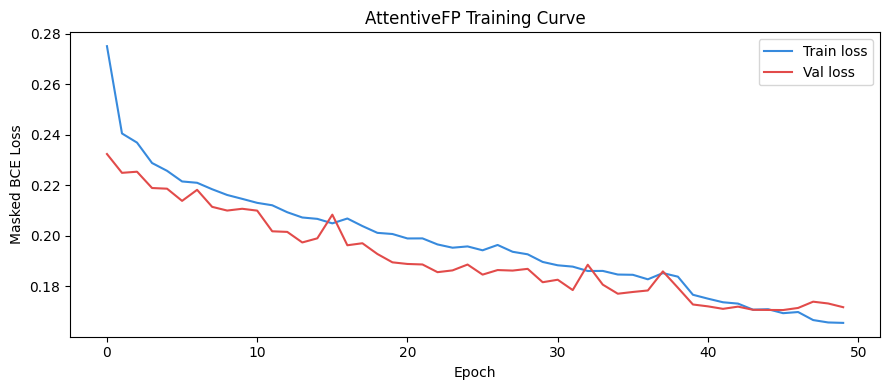

In [17]:
#Cell — Loss curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label='Train loss', color='#378ADD')
ax.plot(val_losses,   label='Val loss',   color='#E24B4A')
ax.set_xlabel('Epoch')
ax.set_ylabel('Masked BCE Loss')
ax.set_title('AttentiveFP Training Curve', fontsize=12, fontweight='500')
ax.legend()
plt.tight_layout()
plt.savefig('/content/gnn_loss_curve.png', dpi=150)
plt.show()

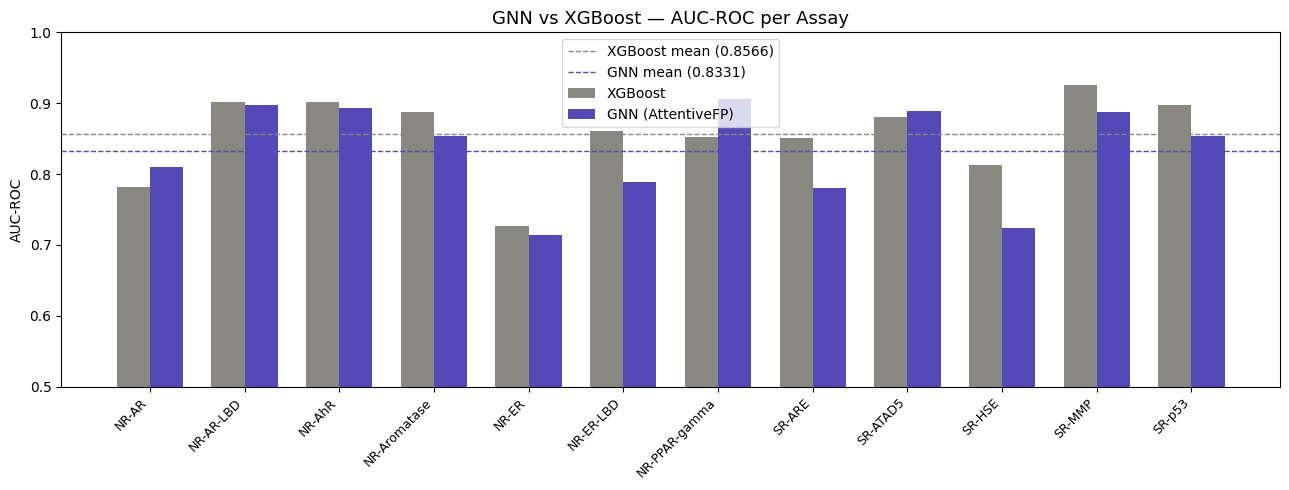

In [18]:
#Cell — GNN vs XGBoost comparison chart
assays = list(gnn_aucs.keys())
gnn_vals = [gnn_aucs[a] for a in assays]
xgb_vals = [xgb_aucs[a] for a in assays]

x   = np.arange(len(assays))
w   = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, xgb_vals, width=w, label='XGBoost',      color='#888780')
ax.bar(x + w/2, gnn_vals, width=w, label='GNN (AttentiveFP)', color='#534AB7')
ax.axhline(0.8566, linestyle='--', linewidth=1,
           color='#888780', label='XGBoost mean (0.8566)')
ax.axhline(gnn_mean, linestyle='--', linewidth=1,
           color='#534AB7', label=f'GNN mean ({gnn_mean:.4f})')
ax.set_xticks(x)
ax.set_xticklabels(assays, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0.5, 1.0)
ax.set_title('GNN vs XGBoost — AUC-ROC per Assay', fontsize=13, fontweight='500')
ax.set_ylabel('AUC-ROC')
ax.legend()
plt.tight_layout()
plt.savefig('/content/gnn_vs_xgboost.png', dpi=150)
plt.show()

In [20]:
#Cell — Save GNN results
import json

gnn_results = {
    'per_assay': gnn_aucs,
    'mean_auc':  round(gnn_mean, 4),
    'baseline':  0.8566,
    'delta':     round(gnn_mean - 0.8566, 4)
}

with open('/content/processed/gnn_results.json', 'w') as f:
    json.dump(gnn_results, f, indent=2)

print("Saved: /content/processed/gnn_results.json")
print(f"\nNotebook 03 complete.")
print(f"GNN mean AUC: {gnn_mean:.4f} vs XGBoost: 0.8566")

Saved: /content/processed/gnn_results.json

Notebook 03 complete.
GNN mean AUC: 0.8331 vs XGBoost: 0.8566
